# Logistic regression from Scratch

# Problem definition
**Logistic regression is a probabilistic linear model** used for binary classification
It uses the **sigmoid function** to map a linear combination of *input features to a value between 0 and 1*, which represents a probability. It is closely related to generalized linear models (GLMs), where a linear predictor is combined with a nonlinear link function

Despite its name, logistic regression is not a regression algorithm, but a **classification algorithm**


# Mathematical formulation
- model equation
- loss function
- optimization method

## 1. Model Definition

### Math definition

Logistic regression uses the **sigmoid function** instead of a straight line:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = wx + b$$

where

- $\hat{y}$ – predicted probability $P(y=1 \mid x)$
- $x$ – input feature
- $w$ – weight
- $b$ – bias (intercept)
- $\sigma(\cdot)$ – sigmoid function

### Definition for machine learning
$$z = \mathbf{w}^T \mathbf{x} + b$$
$$\hat{y} = \sigma(z)$$

where

- $\hat{y}$ – predicted probability (between 0 and 1)
- $\mathbf{x} = (x_1, x_2, \dots, x_n)$ – input features
- $\mathbf{w} = (w_1, w_2, \dots, w_n)$ – weights
- $b$ – bias

### Classification rule

$$\text{class} = \begin{cases} 1 & \text{if } \hat{y} \ge 0.5 \\ 0 & \text{otherwise} \end{cases}$$

## 2. Cost Function

The **Mean Squared Error is not used** for logistic regression:
- With the sigmoid function, MSE becomes **non-convex**, making optimization difficult
- It causes **vanishing gradients**, leading to slow and unstable training
- It has **no probabilistic interpretation** for classification
- It penalizes confident wrong predictions weakly
Instead, we use **Binary Cross-Entropy (Log Loss)** because it is convex, learns faster, and is statistically correct for probability modeling

### Binary Cross-Entropy Loss

$$J(w,b) = -\frac{1}{n} \sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

where

- $y_i$ – actual label ($0$ or $1$)
- $\hat{y}_i$ – predicted probability
- $n$ – number of data points

## 3. Gradient Descent

Logistic regression still uses **gradient descent** to update weights and bias

$$z_i = \mathbf{w}^T \mathbf{x}_i + b$$

$$\hat{y}_i = \sigma(z_i)$$

### Partial Derivatives
- for weight $w_j$:

$$\frac{\partial J}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)x_{ij}$$

- for bias $b$:

$$\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)$$

### Update Rules

$$w_j = w_j - \alpha \frac{\partial J}{\partial w_j}$$

$$b = b - \alpha \frac{\partial J}{\partial b}$$

where

- $\alpha$ – learning rate

## 4. Regularization

### L1 Regularization (Lasso)

$$J(w,b) = -\frac{1}{n} \sum_{i=1}^{n} \Big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\Big] + \lambda \sum |w|$$

Properties:
- Can shrink weights to zero
- Performs feature selection


### L2 Regularization (Ridge)

$$J(w,b) = -\frac{1}{n} \sum_{i=1}^{n} \Big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\Big] + \lambda \sum w^2$$

Properties:
- Shrinks weights smoothly
- Keeps all features

### Effect on Gradient Descent (L2)

$$w = w - \alpha \left(\frac{\partial J}{\partial w} + 2\lambda w \right)$$


# Implementation
> Import of implementation
> class with consistent API from py file

In [1]:
# Import
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Create folders for saved outputs
os.makedirs("outputs/logistic", exist_ok=True)
os.makedirs("outputs/plots/logistic", exist_ok=True)
os.makedirs("outputs/tables/logistic", exist_ok=True)

In [3]:
# Custom
from ml_from_scratch.linear_models.logistic_regression import SimpleLogisticRegression
# from ml_from_scratch.util import train_test_split
from ml_from_scratch.report_utils import (classification_metrics_report, build_classification_comparison_df,
                                          print_report, save_metrics, 
                                          plot_predictions, plot_confusion_matrix)

In [4]:
# Utils
def get_positive_class_proba(model, X):
    # Return probability for class 1 from either shape (n,) or (n, 2)
    proba = np.asarray(model.predict_proba(X))
    if proba.ndim == 2:
        return proba[:, 1]
    return proba.ravel()

# Real dataset example

For real dataset, the Breast Cancer Wisconsin dataset from scikit-learn was used for test

Target:
- 0 = malignant
- 1 = benign

This is a binary classification task, which is a natural use case for Logistic Regression

In [5]:
# 1 - Load dataset
data = load_breast_cancer()
X_real = data.data
y_real = data.target

print("Feature shape:", X_real.shape)
print("Target shape:", y_real.shape)

df_real = pd.DataFrame(X_real, columns=data.feature_names)
df_real["target"] = y_real
df_real.head()

Feature shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
# 2 - Train/test split and scaling
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

scaler_real = StandardScaler()
X_train_real_scaled = scaler_real.fit_transform(X_train_real)
X_test_real_scaled = scaler_real.transform(X_test_real)

In [7]:
# 3 - Train from-scratch model
scratch_real = SimpleLogisticRegression(
    learning_rate=0.01,
    epochs=3000,
    penalty=None,
    alpha=0.0
)

scratch_real.fit(X_train_real_scaled, y_train_real)

y_proba_scratch = get_positive_class_proba(scratch_real, X_test_real_scaled)
y_pred_scratch = (y_proba_scratch >= 0.5).astype(int)

metrics_real_scratch = classification_metrics_report(
    y_test_real, y_pred_scratch, y_proba_scratch
)

print_report("From-scratch Logistic Regression (real dataset)", metrics_real_scratch)
print(classification_report(y_test_real, y_pred_scratch))

From-scratch Logistic Regression (real dataset)
Accuracy: 0.9737
Precision: 0.9859
Recall: 0.9722
F1_score: 0.9790
ROC_AUC: 0.9957
----------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [8]:
# 4 - Train sklearn baseline
sklearn_model = LogisticRegression(max_iter=5000)
sklearn_model.fit(X_train_real_scaled, y_train_real)

y_proba_sklearn = sklearn_model.predict_proba(X_test_real_scaled)[:, 1]
y_pred_sklearn = (y_proba_sklearn >= 0.5).astype(int)

sklearn_metrics = classification_metrics_report(y_test_real, y_pred_sklearn, y_proba_sklearn)
print_report("Sklearn model on real dataset", sklearn_metrics)

Sklearn model on real dataset
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1_score: 0.9861
ROC_AUC: 0.9954
----------------------------------------


In [9]:
# 5 - Compare results
comparison_real = build_classification_comparison_df(
    scratch_metrics=metrics_real_scratch,
    sklearn_metrics=sklearn_metrics
)

comparison_real

,Metric,Scratch,Sklearn
0,Accuracy,0.973684,0.982456
1,Precision,0.985915,0.986111
2,Recall,0.972222,0.986111
3,F1_score,0.979021,0.986111
4,ROC_AUC,0.995701,0.995370


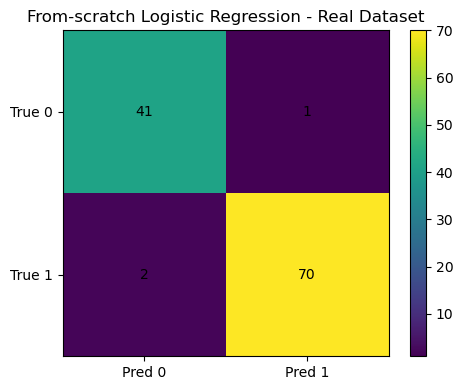

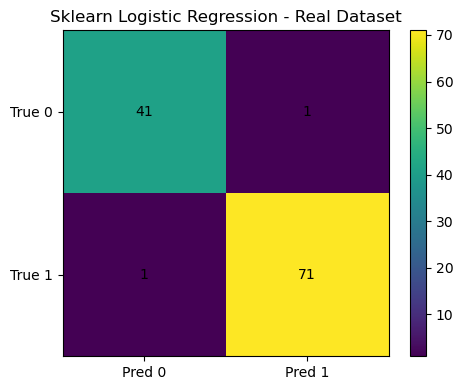

In [10]:
# 6 - Save predictions, tables, and confusion matrices
real_predictions = pd.DataFrame({
    "y_true": y_test_real,
    "y_pred_scratch": y_pred_scratch,
    "y_proba_scratch": y_proba_scratch,
    "y_pred_sklearn": y_pred_sklearn,
    "y_proba_sklearn": y_proba_sklearn
})

real_predictions.to_csv("outputs/tables/logistic/logistic_real_dataset_predictions.csv", index=False)
comparison_real.to_csv("outputs/tables/logistic/logistic_real_dataset_comparison.csv", index=False)

cm_scratch_real = confusion_matrix(y_test_real, y_pred_scratch)
cm_sklearn_real = confusion_matrix(y_test_real, y_pred_sklearn)

plot_confusion_matrix(cm_scratch_real, "From-scratch Logistic Regression - Real Dataset")
plot_confusion_matrix(cm_sklearn_real, "Sklearn Logistic Regression - Real Dataset")

# Small synthetic example

Test the model on artificial binary classification data.

This is useful because:
- the data is simple and controlled
- class separation can be adjusted
- it is easier to debug model behavior

In [11]:
# 1 - Generate synthetic data
X_syn, y_syn = make_classification(
    n_samples=400,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    flip_y=0.03,
    random_state=42
)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn,
    y_syn,
    test_size=0.2,
    random_state=42,
    stratify=y_syn
)

syn_scaler = StandardScaler()
X_syn_train_scaled = syn_scaler.fit_transform(X_syn_train)
X_syn_test_scaled = syn_scaler.transform(X_syn_test)

print("Synthetic train shape:", X_syn_train_scaled.shape)
print("Synthetic test shape:", X_syn_test_scaled.shape)

Synthetic train shape: (320, 6)
Synthetic test shape: (80, 6)


In [12]:
# 2 - Train from-scratch model on synthetic data
scratch_syn_model = SimpleLogisticRegression(
    learning_rate=0.01,
    epochs=5000
)

scratch_syn_model.fit(X_syn_train_scaled, y_syn_train)

y_syn_proba_scratch = get_positive_class_proba(scratch_syn_model, X_syn_test_scaled)
y_syn_pred_scratch = (y_syn_proba_scratch >= 0.5).astype(int)

scratch_syn_metrics = classification_metrics_report(
    y_syn_test,
    y_syn_pred_scratch,
    y_syn_proba_scratch
)
print_report("From-scratch model on synthetic dataset", scratch_syn_metrics)

From-scratch model on synthetic dataset
Accuracy: 0.9750
Precision: 0.9750
Recall: 0.9750
F1_score: 0.9750
ROC_AUC: 0.9594
----------------------------------------


In [13]:
# 3 - Train sklearn baseline on synthetic data
sklearn_syn_model = LogisticRegression(max_iter=5000)
sklearn_syn_model.fit(X_syn_train_scaled, y_syn_train)

y_syn_proba_sklearn = sklearn_syn_model.predict_proba(X_syn_test_scaled)[:, 1]
y_syn_pred_sklearn = (y_syn_proba_sklearn >= 0.5).astype(int)

sklearn_syn_metrics = classification_metrics_report(
    y_syn_test,
    y_syn_pred_sklearn,
    y_syn_proba_sklearn
)
print_report("Sklearn model on synthetic dataset", sklearn_syn_metrics)

Sklearn model on synthetic dataset
Accuracy: 0.9750
Precision: 0.9750
Recall: 0.9750
F1_score: 0.9750
ROC_AUC: 0.9606
----------------------------------------


In [14]:
# 4 - Compare results
comparison_syn = build_classification_comparison_df(
    scratch_metrics=scratch_syn_metrics,
    sklearn_metrics=sklearn_syn_metrics
)

comparison_syn

,Metric,Scratch,Sklearn
0,Accuracy,0.975000,0.975000
1,Precision,0.975000,0.975000
2,Recall,0.975000,0.975000
3,F1_score,0.975000,0.975000
4,ROC_AUC,0.959375,0.960625


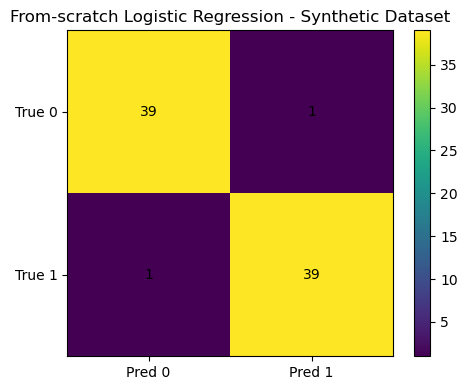

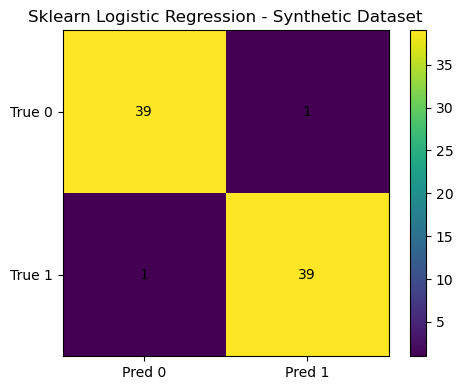

In [15]:
# 5 - Save synthetic results
synthetic_predictions = pd.DataFrame({
    "y_true": y_syn_test,
    "y_pred_scratch": y_syn_pred_scratch,
    "y_proba_scratch": y_syn_proba_scratch,
    "y_pred_sklearn": y_syn_pred_sklearn,
    "y_proba_sklearn": y_syn_proba_sklearn
})

synthetic_predictions.to_csv("outputs/tables/logistic/logistic_synthetic_dataset_predictions.csv", index=False)
comparison_syn.to_csv("outputs/tables/logistic/logistic_synthetic_dataset_comparison.csv", index=False)

cm_scratch_syn = confusion_matrix(y_syn_test, y_syn_pred_scratch)
cm_sklearn_syn = confusion_matrix(y_syn_test, y_syn_pred_sklearn)

plot_confusion_matrix(cm_scratch_syn, "From-scratch Logistic Regression - Synthetic Dataset")
plot_confusion_matrix(cm_sklearn_syn, "Sklearn Logistic Regression - Synthetic Dataset")

# Save all results summary

In [16]:
logistic_results = {
    "real_dataset": {
        "scratch": metrics_real_scratch,
        "sklearn": sklearn_metrics
    },
    "synthetic_dataset": {
        "scratch": scratch_syn_metrics,
        "sklearn": sklearn_syn_metrics
    }
}

save_metrics("outputs/logistic/logistic_results.json", logistic_results)

print("All results saved to outputs/logistic")

All results saved to outputs/logistic


# Conclusion

The small difference between the two models is expected because sklearn uses a highly optimized implementation and applies L2 regularization by default, while the from-scratch model was trained with a simpler gradient descent setup

On the synthetic dataset, both models achieved almost identical results, which confirms that the implementation learns a reasonable decision boundary on controlled binary classification data

Feature scaling was important for stable training because Logistic Regression with gradient descent is sensitive to feature magnitude

Overall, the implementation behaves correctly and produces results comparable to sklearn on clean binary classification tasks. The saved predictions, comparison tables, metrics JSON, and confusion matrices make the experiment easier to inspect and reproduce later